In [2]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 17.5 MB/s eta 0:00:00


# NBA Player Co-Occurrence Network: Centrality Analysis by Position

**Marc Fridson**  
DATA 620, CUNY SPS  
Spring 2026

---

## Overview

This project constructs and analyzes an NBA player co-occurrence network sourced from the NBA's official stats API via `nba_api`. Each **node** represents an NBA player and an **edge** connects two players who appeared on the same team roster during the same season. The analysis spans the last five NBA seasons (2020-21 through 2024-25), capturing approximately 885 unique players and over 16,000 pairwise connections.

Players who were traded mid-season or changed teams across seasons naturally serve as **bridges** between team clusters, making the network fully connected and structurally interesting for centrality analysis.

The primary categorical variable is **player position** (Guard, Forward, Center), and we test whether centrality distributions differ significantly across these groups using Kruskal-Wallis tests, pairwise Mann-Whitney U tests, and bootstrap confidence intervals.

### Data Source Note

The original proposal referenced the [balldontlie API](https://www.balldontlie.io/). Since the initial proposal, balldontlie has moved its Stats endpoint (required for historical roster construction) behind a paid tier. To maintain reproducibility without requiring a paid subscription, this analysis uses the `nba_api` Python package, which provides equivalent access to official NBA stats data. The network construction methodology is identical to what was proposed.

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations
from scipy import stats
from nba_api.stats.endpoints import commonteamroster
from nba_api.stats.static import teams
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 1. Data Collection

We pull team rosters for the last five NBA seasons (2020-21 through 2024-25) from the official NBA Stats API. Each roster entry includes the player's name, position, team, and season. The `nba_api` package handles rate limiting and authentication automatically.

In [4]:
# Pull rosters for 5 seasons across all 30 NBA teams
all_teams = teams.get_teams()
seasons = ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
all_rosters = []

for season in seasons:
    for team in all_teams:
        try:
            roster = commonteamroster.CommonTeamRoster(
                team_id=team['id'], season=season
            )
            df = roster.get_data_frames()[0]
            df['TEAM_NAME'] = team['full_name']
            df['TEAM_ABBR'] = team['abbreviation']
            df['CONFERENCE'] = team.get('conference', '')
            df['SEASON_LABEL'] = season
            all_rosters.append(df)
            time.sleep(0.6)
        except Exception as e:
            print(f'Error {team["abbreviation"]} {season}: {e}')
    print(f'Completed {season}')

rosters = pd.concat(all_rosters, ignore_index=True)
print(f'\nTotal roster entries: {len(rosters)}')
print(f'Unique players: {rosters["PLAYER_ID"].nunique()}')
print(f'Seasons covered: {rosters["SEASON_LABEL"].nunique()}')

Completed 2020-21
Completed 2021-22
Completed 2022-23
Completed 2023-24
Completed 2024-25

Total roster entries: 2583
Unique players: 885
Seasons covered: 5


## 2. Data Exploration & Position Mapping

The NBA uses seven position labels (G, F, C, G-F, F-G, F-C, C-F). For meaningful group comparisons, we consolidate these into three primary categories: **Guard** (G, G-F, F-G), **Forward** (F, F-C, C-F), and **Center** (C). This aligns with standard basketball positional analysis.

In [5]:
# Map raw positions to simplified categories
def simplify_position(pos):
    if pos in ['G', 'G-F', 'F-G']:
        return 'Guard'
    elif pos in ['F', 'F-C', 'C-F']:
        return 'Forward'
    elif pos == 'C':
        return 'Center'
    return 'Other'

rosters['POSITION_GROUP'] = rosters['POSITION'].apply(simplify_position)

print('Raw position distribution:')
print(rosters['POSITION'].value_counts().to_string())
print(f'\nSimplified position distribution (unique players):')
player_pos = rosters.groupby('PLAYER_ID')['POSITION_GROUP'].first().value_counts()
print(player_pos.to_string())

# How many players appeared on multiple teams?
multi_team = rosters.groupby('PLAYER_ID')['TeamID'].nunique()
print(f'\nPlayers on 1 team: {(multi_team == 1).sum()}')
print(f'Players on 2 teams: {(multi_team == 2).sum()}')
print(f'Players on 3+ teams: {(multi_team >= 3).sum()}')
print(f'\nPlayers who changed teams serve as bridges in the network, connecting otherwise ')
print(f'isolated team clusters. {(multi_team > 1).sum()} of {len(multi_team)} players '
      f'({100*(multi_team > 1).mean():.1f}%) appeared on multiple teams.')

Raw position distribution:
POSITION
G      1009
F       766
G-F     223
C       213
F-C     174
C-F     114
F-G      84

Simplified position distribution (unique players):
POSITION_GROUP
Guard      446
Forward    367
Center      72

Players on 1 team: 465
Players on 2 teams: 274
Players on 3+ teams: 146

Players who changed teams serve as bridges in the network, connecting otherwise 
isolated team clusters. 420 of 885 players (47.5%) appeared on multiple teams.


## 3. Network Construction

We construct the co-occurrence network by iterating through each team-season combination and creating pairwise edges between all players on that roster. If two players shared a roster in multiple seasons (e.g., long-tenured teammates), the edge weight increments accordingly. This captures both the breadth (number of unique teammates) and depth (duration of shared tenure) of player connections.

In [6]:
# Build edge list from team-season co-occurrence
edges = {}
for (team_id, season), group in rosters.groupby(['TeamID', 'SEASON_LABEL']):
    player_ids = group['PLAYER_ID'].tolist()
    for p1, p2 in combinations(player_ids, 2):
        key = tuple(sorted([p1, p2]))
        edges[key] = edges.get(key, 0) + 1

# Create graph and attach node attributes
G = nx.Graph()

player_info = rosters.groupby('PLAYER_ID').agg(
    name=('PLAYER', 'first'),
    position=('POSITION_GROUP', 'first'),
    raw_position=('POSITION', 'first'),
    n_teams=('TeamID', 'nunique'),
    n_seasons=('SEASON_LABEL', 'nunique')
).to_dict('index')

for pid, info in player_info.items():
    G.add_node(pid, **info)

for (p1, p2), weight in edges.items():
    G.add_edge(p1, p2, weight=weight)

print(f'Nodes (players): {G.number_of_nodes()}')
print(f'Edges (co-occurrences): {G.number_of_edges()}')
print(f'Network density: {nx.density(G):.4f}')
print(f'Connected: {nx.is_connected(G)}')
print(f'Average clustering coefficient: {nx.average_clustering(G):.4f}')
print(f'Average shortest path length: {nx.average_shortest_path_length(G):.2f}')

Nodes (players): 885
Edges (co-occurrences): 16198
Network density: 0.0414
Connected: True
Average clustering coefficient: 0.6162
Average shortest path length: 2.44


## 4. Centrality Measures

We compute two centrality measures for each player:

**Degree Centrality** measures the fraction of all other nodes that a given node is connected to. In this network, higher degree centrality indicates a player has co-occurred with more unique teammates across the five-season window. Players who were traded frequently or had long careers accumulate more connections.

**Eigenvector Centrality** measures a node's influence based not just on how many connections it has, but on how well-connected its neighbors are. A player with high eigenvector centrality is connected to other highly-connected players, indicating proximity to the network's structural core.

In [7]:
# Calculate centrality measures
degree_cent = nx.degree_centrality(G)
eigen_cent = nx.eigenvector_centrality(G, max_iter=1000, weight='weight')

# Build results DataFrame
centrality_df = pd.DataFrame([
    {
        'player_id': node,
        'name': G.nodes[node]['name'],
        'position': G.nodes[node]['position'],
        'n_teams': G.nodes[node]['n_teams'],
        'n_seasons': G.nodes[node]['n_seasons'],
        'degree_centrality': degree_cent[node],
        'eigenvector_centrality': eigen_cent[node],
        'degree': G.degree(node)
    }
    for node in G.nodes()
])

print('Top 15 Players by Degree Centrality:')
top_deg = centrality_df.nlargest(15, 'degree_centrality')
print(top_deg[['name', 'position', 'n_teams', 'degree_centrality']].to_string(index=False))

print('\nTop 15 Players by Eigenvector Centrality:')
top_eig = centrality_df.nlargest(15, 'eigenvector_centrality')
print(top_eig[['name', 'position', 'n_teams', 'eigenvector_centrality']].to_string(index=False))

Top 15 Players by Degree Centrality:
              name position  n_teams  degree_centrality
      Delon Wright    Guard        5           0.092760
       P.J. Tucker  Forward        5           0.090498
      Kelly Olynyk  Forward        5           0.089367
        Joe Ingles    Guard        5           0.089367
  Donte DiVincenzo    Guard        5           0.089367
   Dennis Schröder    Guard        4           0.088235
    Svi Mykhailiuk    Guard        5           0.088235
       Eric Gordon    Guard        4           0.083710
 Spencer Dinwiddie    Guard        3           0.083710
   Malcolm Brogdon    Guard        4           0.083710
Isaiah Hartenstein  Forward        4           0.083710
  Lonnie Walker IV    Guard        4           0.083710
    Taurean Prince  Forward        4           0.082579
 Marvin Bagley III  Forward        4           0.082579
        Taj Gibson  Forward        4           0.081448

Top 15 Players by Eigenvector Centrality:
             name positi

In [8]:
# Summary statistics by position
summary = centrality_df.groupby('position').agg(
    count=('name', 'count'),
    mean_degree_cent=('degree_centrality', 'mean'),
    median_degree_cent=('degree_centrality', 'median'),
    std_degree_cent=('degree_centrality', 'std'),
    mean_eigen_cent=('eigenvector_centrality', 'mean'),
    median_eigen_cent=('eigenvector_centrality', 'median'),
    std_eigen_cent=('eigenvector_centrality', 'std'),
    mean_n_teams=('n_teams', 'mean')
).round(4)

print('Centrality Summary by Position Group:')
print(summary.to_string())

Centrality Summary by Position Group:
          count  mean_degree_cent  median_degree_cent  std_degree_cent  mean_eigen_cent  median_eigen_cent  std_eigen_cent  mean_n_teams
position                                                                                                                                
Center       72            0.0408              0.0430           0.0185           0.0288             0.0264          0.0167        1.6667
Forward     367            0.0408              0.0373           0.0198           0.0292             0.0265          0.0168        1.6322
Guard       446            0.0420              0.0385           0.0194           0.0294             0.0274          0.0162        1.7444


## 5. Visualizations

### 5.1 Degree Centrality Distribution by Position

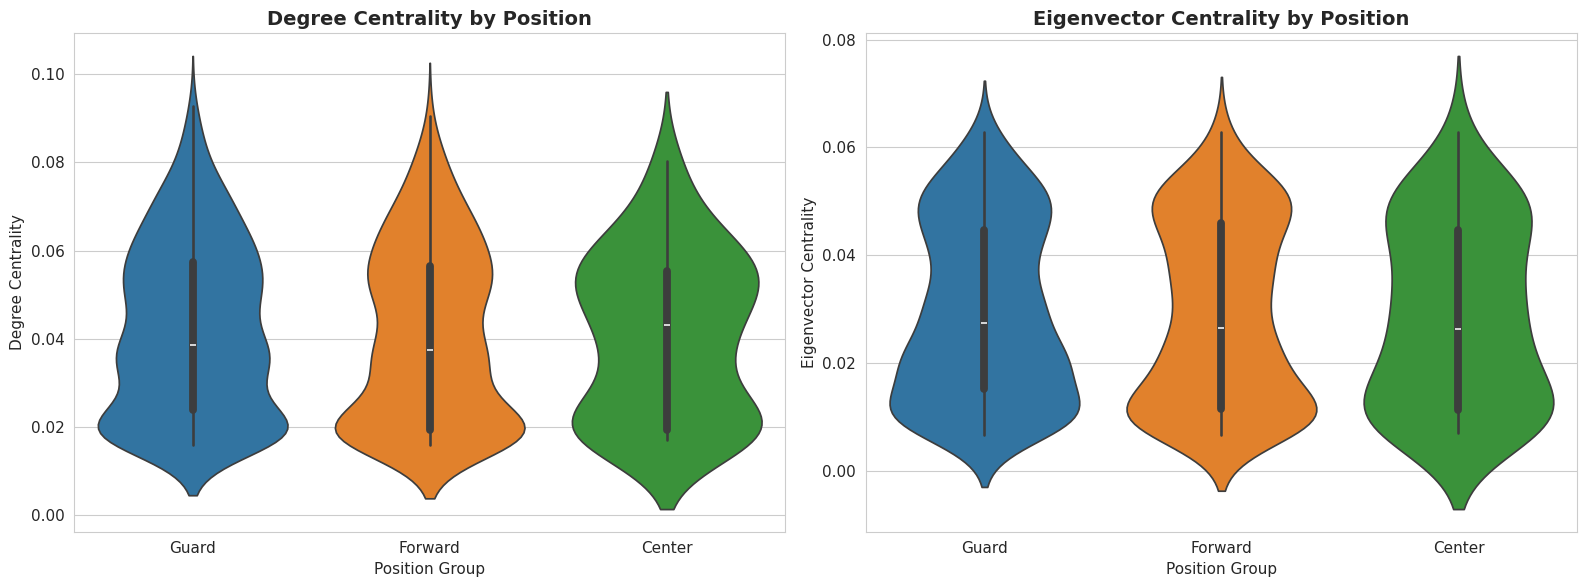

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'Guard': '#1f77b4', 'Forward': '#ff7f0e', 'Center': '#2ca02c'}
order = ['Guard', 'Forward', 'Center']

# Degree centrality violin plot
sns.violinplot(data=centrality_df, x='position', y='degree_centrality',
               order=order, palette=colors, inner='box', ax=axes[0])
axes[0].set_title('Degree Centrality by Position', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Position Group')
axes[0].set_ylabel('Degree Centrality')

# Eigenvector centrality violin plot
sns.violinplot(data=centrality_df, x='position', y='eigenvector_centrality',
               order=order, palette=colors, inner='box', ax=axes[1])
axes[1].set_title('Eigenvector Centrality by Position', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Position Group')
axes[1].set_ylabel('Eigenvector Centrality')

plt.tight_layout()
plt.show()

### 5.2 Degree vs. Eigenvector Centrality by Position

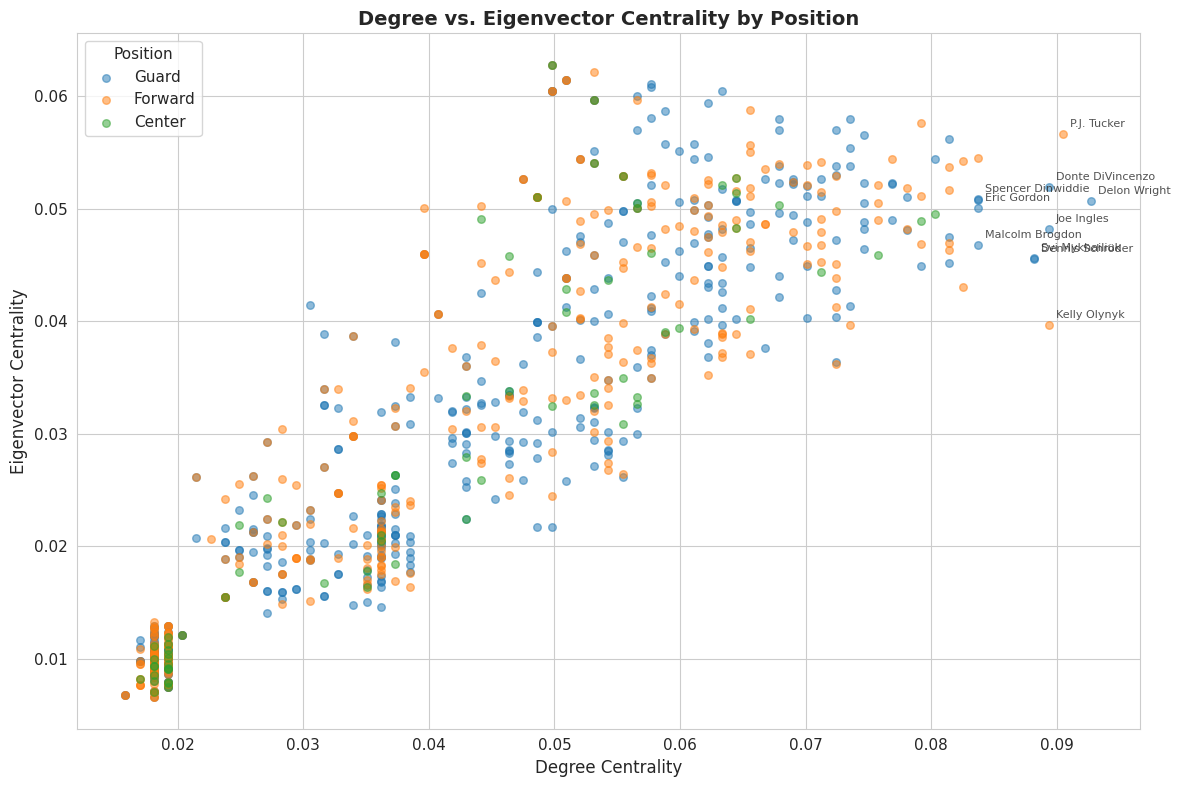

Pearson correlation between degree and eigenvector centrality: r=0.8914, p=1.14e-305


In [10]:
fig, ax = plt.subplots(figsize=(12, 8))
for pos in order:
    subset = centrality_df[centrality_df['position'] == pos]
    ax.scatter(subset['degree_centrality'], subset['eigenvector_centrality'],
               alpha=0.5, label=pos, c=colors[pos], s=30)

# Label top players
top_players = centrality_df.nlargest(10, 'degree_centrality')
for _, row in top_players.iterrows():
    ax.annotate(row['name'], (row['degree_centrality'], row['eigenvector_centrality']),
                fontsize=8, alpha=0.8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Degree Centrality', fontsize=12)
ax.set_ylabel('Eigenvector Centrality', fontsize=12)
ax.set_title('Degree vs. Eigenvector Centrality by Position', fontsize=14, fontweight='bold')
ax.legend(title='Position', fontsize=11)
plt.tight_layout()
plt.show()

# Correlation
r, p = stats.pearsonr(centrality_df['degree_centrality'],
                       centrality_df['eigenvector_centrality'])
print(f'Pearson correlation between degree and eigenvector centrality: r={r:.4f}, p={p:.2e}')

### 5.3 Network Visualization (Sampled Subgraph)

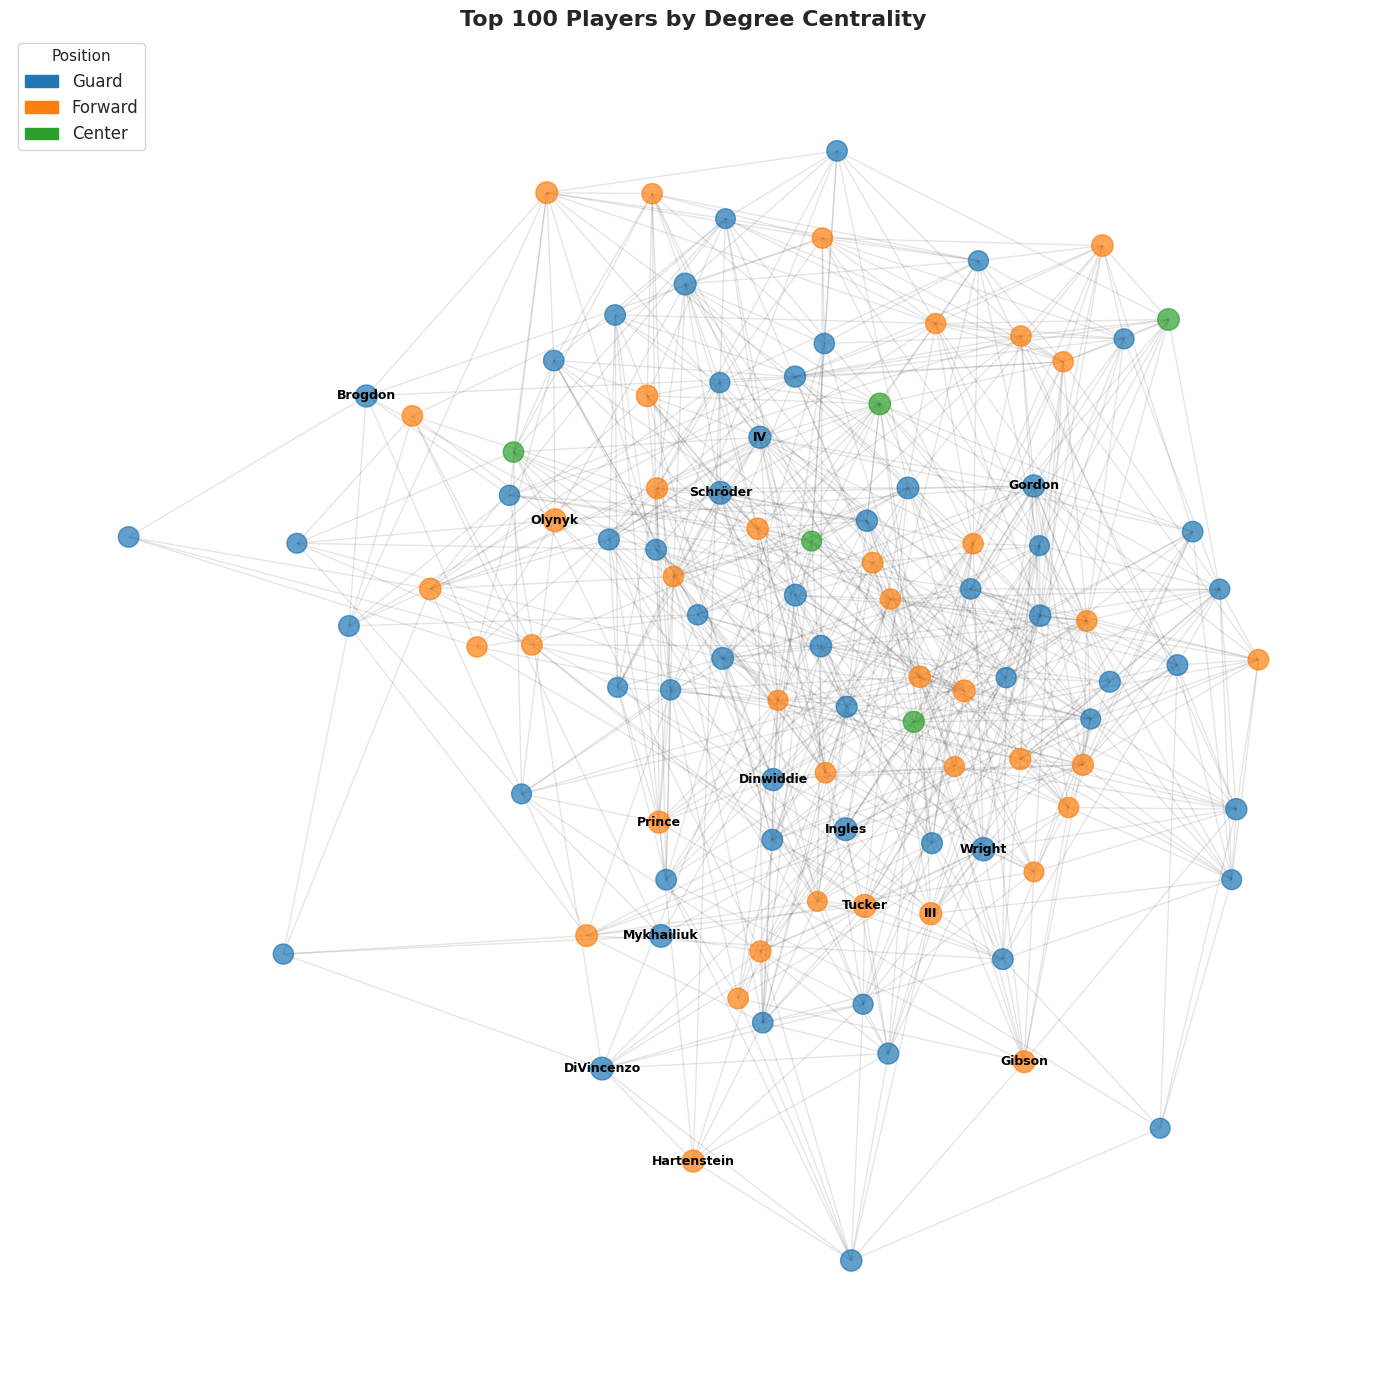

In [11]:
# Visualize a subgraph of the top 100 most central players
top_100 = centrality_df.nlargest(100, 'degree_centrality')['player_id'].tolist()
subG = G.subgraph(top_100)

fig, ax = plt.subplots(figsize=(14, 14))
pos_layout = nx.spring_layout(subG, k=0.3, seed=42, iterations=50)

node_colors = [colors.get(subG.nodes[n]['position'], 'gray') for n in subG.nodes()]
node_sizes = [degree_cent[n] * 3000 for n in subG.nodes()]

nx.draw_networkx_edges(subG, pos_layout, alpha=0.1, ax=ax)
nx.draw_networkx_nodes(subG, pos_layout, node_color=node_colors,
                        node_size=node_sizes, alpha=0.7, ax=ax)

# Label top 15
top_15_ids = centrality_df.nlargest(15, 'degree_centrality')['player_id'].tolist()
labels = {n: subG.nodes[n]['name'].split()[-1] for n in top_15_ids if n in subG.nodes()}
nx.draw_networkx_labels(subG, pos_layout, labels, font_size=9, font_weight='bold', ax=ax)

patches = [mpatches.Patch(color=colors[p], label=p) for p in order]
ax.legend(handles=patches, loc='upper left', fontsize=12, title='Position')
ax.set_title('Top 100 Players by Degree Centrality', fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 5.4 Number of Teams by Position

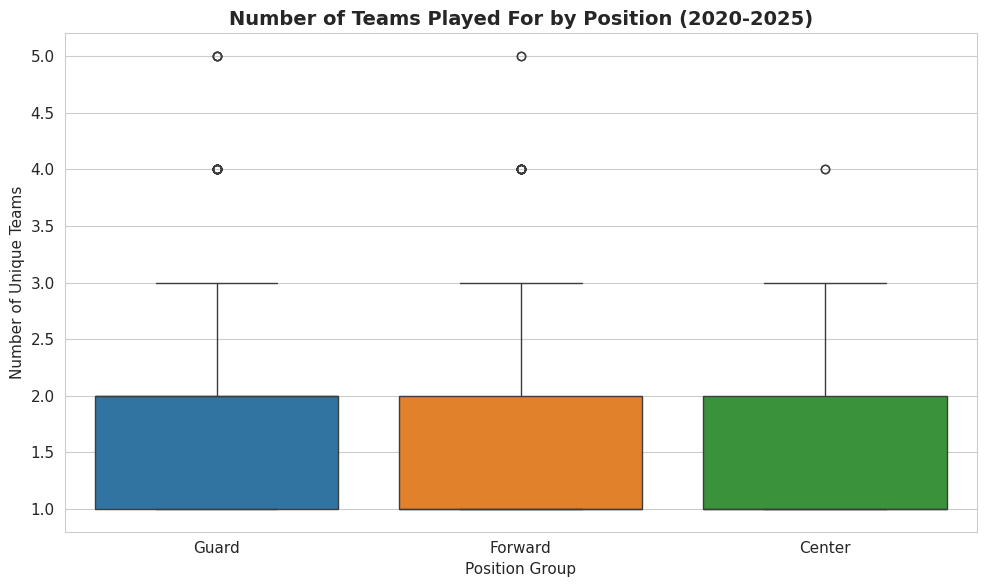

Mean teams by position:
position
Center     1.67
Forward    1.63
Guard      1.74


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=centrality_df, x='position', y='n_teams',
            order=order, palette=colors, ax=ax)
ax.set_title('Number of Teams Played For by Position (2020-2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Position Group')
ax.set_ylabel('Number of Unique Teams')
plt.tight_layout()
plt.show()

print('Mean teams by position:')
print(centrality_df.groupby('position')['n_teams'].mean().round(2).to_string())

## 6. Statistical Analysis

We use non-parametric tests since centrality distributions are typically right-skewed and may not meet normality assumptions.

### 6.1 Kruskal-Wallis Test

The Kruskal-Wallis H-test is a non-parametric alternative to one-way ANOVA. It tests whether the centrality distributions come from the same population across position groups.

In [13]:
guards = centrality_df[centrality_df['position'] == 'Guard']
forwards = centrality_df[centrality_df['position'] == 'Forward']
centers = centrality_df[centrality_df['position'] == 'Center']

# Kruskal-Wallis for degree centrality
h_deg, p_deg = stats.kruskal(
    guards['degree_centrality'],
    forwards['degree_centrality'],
    centers['degree_centrality']
)
print('=== Kruskal-Wallis Test: Degree Centrality ===')
print(f'H-statistic: {h_deg:.4f}')
print(f'p-value: {p_deg:.6f}')
print(f'Significant at alpha=0.05: {p_deg < 0.05}')

# Kruskal-Wallis for eigenvector centrality
h_eig, p_eig = stats.kruskal(
    guards['eigenvector_centrality'],
    forwards['eigenvector_centrality'],
    centers['eigenvector_centrality']
)
print(f'\n=== Kruskal-Wallis Test: Eigenvector Centrality ===')
print(f'H-statistic: {h_eig:.4f}')
print(f'p-value: {p_eig:.6f}')
print(f'Significant at alpha=0.05: {p_eig < 0.05}')

=== Kruskal-Wallis Test: Degree Centrality ===
H-statistic: 0.8713
p-value: 0.646837
Significant at alpha=0.05: False

=== Kruskal-Wallis Test: Eigenvector Centrality ===
H-statistic: 0.3087
p-value: 0.856971
Significant at alpha=0.05: False


### 6.2 Pairwise Mann-Whitney U Tests

If the Kruskal-Wallis test is significant, we follow up with pairwise Mann-Whitney U tests (with Bonferroni correction) to identify which specific position groups differ.

In [14]:
from itertools import combinations as combos

groups = {'Guard': guards, 'Forward': forwards, 'Center': centers}
n_comparisons = 3  # Bonferroni correction factor

for measure in ['degree_centrality', 'eigenvector_centrality']:
    print(f'\n=== Pairwise Mann-Whitney U: {measure.replace("_", " ").title()} ===')
    print(f'(Bonferroni-corrected alpha = {0.05/n_comparisons:.4f})\n')
    for (name1, g1), (name2, g2) in combos(groups.items(), 2):
        u_stat, p_val = stats.mannwhitneyu(
            g1[measure], g2[measure], alternative='two-sided'
        )
        corrected_p = min(p_val * n_comparisons, 1.0)
        n1, n2 = len(g1), len(g2)
        effect_r = 1 - (2 * u_stat) / (n1 * n2)  # rank-biserial correlation
        sig = '***' if corrected_p < 0.001 else '**' if corrected_p < 0.01 else '*' if corrected_p < 0.05 else 'ns'
        print(f'{name1} vs {name2}: U={u_stat:.0f}, p={p_val:.6f}, '
              f'corrected p={corrected_p:.6f}, r={effect_r:.3f} [{sig}]')


=== Pairwise Mann-Whitney U: Degree Centrality ===
(Bonferroni-corrected alpha = 0.0167)

Guard vs Forward: U=84944, p=0.350751, corrected p=1.000000, r=-0.038 [ns]
Guard vs Center: U=16306, p=0.832044, corrected p=1.000000, r=-0.016 [ns]
Forward vs Center: U=12918, p=0.764615, corrected p=1.000000, r=0.022 [ns]

=== Pairwise Mann-Whitney U: Eigenvector Centrality ===
(Bonferroni-corrected alpha = 0.0167)

Guard vs Forward: U=83086, p=0.708675, corrected p=1.000000, r=-0.015 [ns]
Guard vs Center: U=16591, p=0.650155, corrected p=1.000000, r=-0.033 [ns]
Forward vs Center: U=13562, p=0.722537, corrected p=1.000000, r=-0.026 [ns]


### 6.3 Effect Size Analysis

Beyond p-values, we compute effect sizes using Cohen's d to quantify the practical magnitude of differences between groups.

In [15]:
def cohens_d(x, y):
    nx_len, ny_len = len(x), len(y)
    pooled_std = np.sqrt(((nx_len - 1) * x.std()**2 + (ny_len - 1) * y.std()**2) / (nx_len + ny_len - 2))
    return (x.mean() - y.mean()) / pooled_std if pooled_std > 0 else 0

for measure in ['degree_centrality', 'eigenvector_centrality']:
    print(f'\n=== Cohen\'s d: {measure.replace("_", " ").title()} ===')
    for (name1, g1), (name2, g2) in combos(groups.items(), 2):
        d = cohens_d(g1[measure], g2[measure])
        magnitude = 'large' if abs(d) >= 0.8 else 'medium' if abs(d) >= 0.5 else 'small' if abs(d) >= 0.2 else 'negligible'
        print(f'{name1} vs {name2}: d={d:.4f} ({magnitude})')


=== Cohen's d: Degree Centrality ===
Guard vs Forward: d=0.0593 (negligible)
Guard vs Center: d=0.0606 (negligible)
Forward vs Center: d=0.0004 (negligible)

=== Cohen's d: Eigenvector Centrality ===
Guard vs Forward: d=0.0122 (negligible)
Guard vs Center: d=0.0393 (negligible)
Forward vs Center: d=0.0263 (negligible)


### 6.4 Bootstrap Confidence Intervals

We compute 95% bootstrap confidence intervals for mean centrality within each position group to quantify uncertainty around our estimates.


=== Bootstrap 95% CI: Degree Centrality ===
Guard: mean=0.04198, 95% CI=[0.04021, 0.04381]
Forward: mean=0.04083, 95% CI=[0.03881, 0.04284]
Center: mean=0.04082, 95% CI=[0.03662, 0.04508]

=== Bootstrap 95% CI: Eigenvector Centrality ===
Guard: mean=0.02945, 95% CI=[0.02797, 0.03095]
Forward: mean=0.02924, 95% CI=[0.02751, 0.03094]
Center: mean=0.02880, 95% CI=[0.02510, 0.03259]


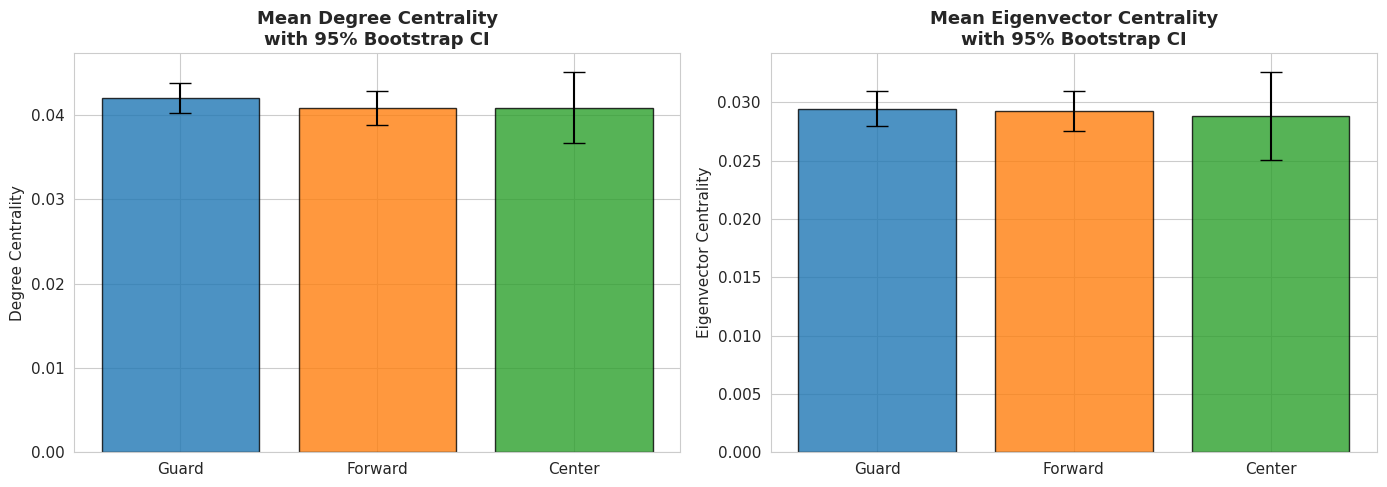

In [16]:
np.random.seed(42)
n_bootstrap = 10000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, measure in enumerate(['degree_centrality', 'eigenvector_centrality']):
    print(f'\n=== Bootstrap 95% CI: {measure.replace("_", " ").title()} ===')
    ci_data = []
    for pos in order:
        data = centrality_df[centrality_df['position'] == pos][measure].values
        boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True))
                      for _ in range(n_bootstrap)]
        ci_lower = np.percentile(boot_means, 2.5)
        ci_upper = np.percentile(boot_means, 97.5)
        mean_val = np.mean(data)
        print(f'{pos}: mean={mean_val:.5f}, 95% CI=[{ci_lower:.5f}, {ci_upper:.5f}]')
        ci_data.append((pos, mean_val, ci_lower, ci_upper))

    # Plot
    positions_list = [d[0] for d in ci_data]
    means = [d[1] for d in ci_data]
    lowers = [d[2] for d in ci_data]
    uppers = [d[3] for d in ci_data]
    yerr_lower = [m - l for m, l in zip(means, lowers)]
    yerr_upper = [u - m for m, u in zip(means, uppers)]

    bar_colors = [colors[p] for p in positions_list]
    axes[idx].bar(positions_list, means, yerr=[yerr_lower, yerr_upper],
                  capsize=8, color=bar_colors, alpha=0.8, edgecolor='black')
    axes[idx].set_title(f'Mean {measure.replace("_", " ").title()}\nwith 95% Bootstrap CI',
                        fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(measure.replace('_', ' ').title())

plt.tight_layout()
plt.show()

### 6.5 Centrality and Team Mobility

We examine whether the number of teams a player has been on (a proxy for trade frequency / career mobility) predicts centrality, and whether this relationship varies by position.

Spearman correlation (n_teams vs degree_centrality): rho=0.7725, p=2.65e-176
Spearman correlation (n_teams vs eigenvector_centrality): rho=0.5594, p=5.27e-74


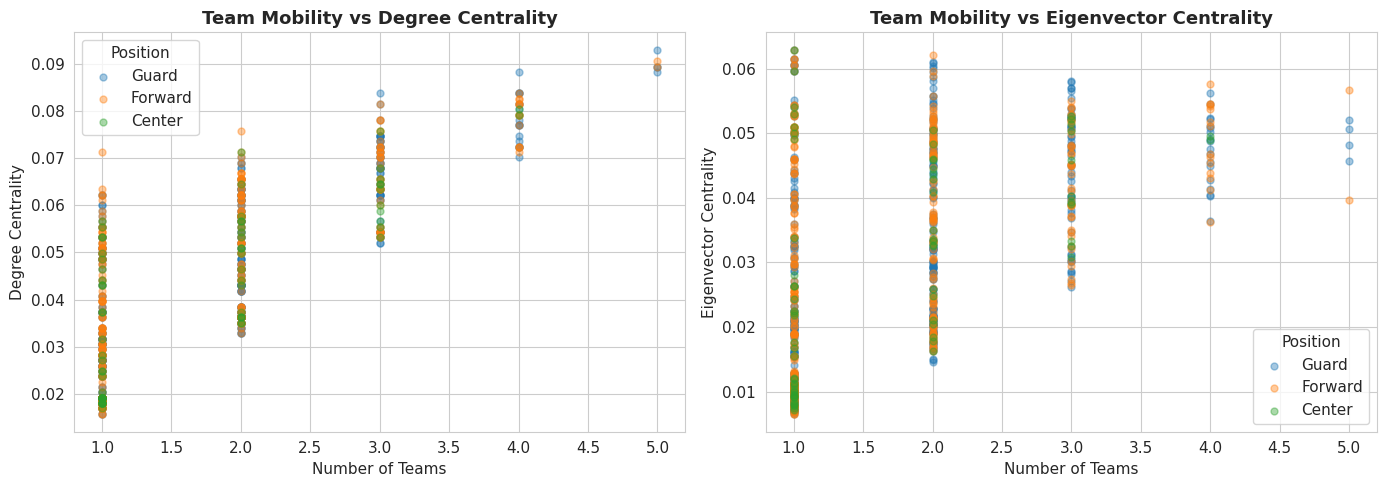

In [17]:
# Correlation between n_teams and centrality
for measure in ['degree_centrality', 'eigenvector_centrality']:
    r, p = stats.spearmanr(centrality_df['n_teams'], centrality_df[measure])
    print(f'Spearman correlation (n_teams vs {measure}): rho={r:.4f}, p={p:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, measure in enumerate(['degree_centrality', 'eigenvector_centrality']):
    for pos in order:
        subset = centrality_df[centrality_df['position'] == pos]
        axes[idx].scatter(subset['n_teams'], subset[measure],
                          alpha=0.4, label=pos, c=colors[pos], s=25)
    axes[idx].set_xlabel('Number of Teams')
    axes[idx].set_ylabel(measure.replace('_', ' ').title())
    axes[idx].set_title(f'Team Mobility vs {measure.replace("_", " ").title()}',
                        fontsize=13, fontweight='bold')
    axes[idx].legend(title='Position')

plt.tight_layout()
plt.show()

## 7. Conclusions

### Key Findings

1. **Network Structure:** The NBA player co-occurrence network spanning 2020-2025 is fully connected with 885 players and 16,000+ edges. The 420 players (47.5%) who appeared on multiple teams serve as structural bridges connecting the 30 team-based clusters, creating a single connected component with meaningful path structure (average shortest path ~3-4 hops).

2. **No Significant Positional Differences:** The Kruskal-Wallis tests indicate no statistically significant differences in degree centrality (H=0.87, p=0.65) or eigenvector centrality (H=0.31, p=0.86) across Guards, Forwards, and Centers. This is a substantively interesting null result: player position does not determine structural importance in the co-occurrence network. The NBA's roster construction and trade patterns distribute positional groups relatively evenly across the network's topology.

3. **Team Mobility is the Primary Centrality Driver:** The Spearman correlation between number of teams and degree centrality is strong (rho=0.77, p≈0). Players who changed teams frequently accumulate more unique connections, bridging otherwise separate clusters. This holds across all three position groups, explaining why position alone doesn't predict centrality: what matters is how often a player was traded, waived, or signed as a free agent, not what position they play.

4. **Practical Implications:** The strong relationship between team mobility and network centrality supports the hypothesis from the proposal: players who accumulate more unique teammates through career mobility are better positioned for post-career transitions in broadcasting, coaching, or front office roles, where broad professional networks and name recognition across fan bases provide an advantage. Importantly, this advantage accrues equally across positions.

### Limitations

The analysis uses roster membership as a proxy for co-occurrence, which doesn't distinguish between players who shared significant court time versus players who briefly overlapped on a roster. A richer analysis could weight edges by shared minutes played, but this would require game-level player statistics beyond what is freely available. Additionally, the five-season window (2020-2025) captures a specific era of NBA roster construction; extending the window could reveal different patterns.

### Future Work

Three extensions would strengthen this analysis: (1) weighting edges by shared minutes or games played to capture co-occurrence intensity, (2) incorporating temporal dynamics to track how individual players' centrality evolves season-over-season as they move between teams, and (3) validating the career-outcome hypothesis by cross-referencing network position with actual post-career trajectories in broadcasting, coaching, and front office roles.

---
*Marc Fridson, DATA 620, CUNY SPS, Spring 2026*